# Phase 4: PCA Analysis

## Why this PCA is different

Previous attempts ran PCA on questionnaire **items** (PHQ-9 + GAD-7), which always produces one dominant component because items within a scale are designed to be correlated.

This analysis runs PCA on **conceptually diverse variables** spanning four domains:
- **Mental health** — depression, anxiety, flourishing, loneliness
- **Financial/social stress** — income, housing, food insecurity
- **Behaviors** — substance use, self-injury, therapy
- **Context** — age, year in school, institution type/size

Variables from different domains have low cross-domain correlations, so PCA can find genuinely distinct components.


## Setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('HMS_clean.csv', low_memory=False)

# ── Variable selection ────────────────────────────────────────────────────
VAR_INFO = {
    # Mental health
    'phq9_total':       ('Mental Health', 'Depression score (PHQ-9, 0-27)'),
    'gad7_total':       ('Mental Health', 'Anxiety score (GAD-7, 0-21)'),
    'flourishing':      ('Mental Health', 'Flourishing (Diener, 8-56, higher=better)'),
    'loneliness':       ('Mental Health', 'Loneliness (UCLA, 3-9)'),
    # Financial stress
    'low_income':       ('Financial',     'Pell grant recipient (low income proxy)'),
    'housing_insecure': ('Financial',     'Housing insecurity'),
    'food_worry':       ('Financial',     'Food insecurity'),
    # Behaviors
    'sub_any':          ('Behavior',      'Any substance use'),
    'sib_any':          ('Behavior',      'Non-suicidal self-injury'),
    'ther_any':         ('Behavior',      'Currently in therapy'),
    # Context
    'age':              ('Context',       'Student age'),
    'international':    ('Context',       'International student'),
    'yr_sch':           ('Context',       'Year in school (1-5)'),
    'inst_public':      ('Context',       'Public institution'),
    'inst_size':        ('Context',       'Institution size (1-5)'),
}

COLS = list(VAR_INFO.keys())
LABELS = [VAR_INFO[c][1].split('(')[0].strip() for c in COLS]
DOMAINS = [VAR_INFO[c][0] for c in COLS]
DOMAIN_COLORS = {'Mental Health':'steelblue','Financial':'tomato',
                 'Behavior':'darkorange','Context':'mediumseagreen'}

df_sub = df[COLS].apply(pd.to_numeric, errors='coerce').copy()
df_sub['food_worry'] = (df_sub['food_worry'] >= 2).astype(float)  # recode to binary

df_pca = df_sub.dropna()
X_raw = df_pca.values
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

print(f"PCA input: {X.shape[0]:,} students x {X.shape[1]} variables")
print(f"Variables: {len(COLS)}")
print()
for domain in ['Mental Health','Financial','Behavior','Context']:
    vars_d = [c for c in COLS if VAR_INFO[c][0]==domain]
    print(f"  {domain:15s}: {vars_d}")


PCA input: 151,870 students x 15 variables
Variables: 15

  Mental Health  : ['phq9_total', 'gad7_total', 'flourishing', 'loneliness']
  Financial      : ['low_income', 'housing_insecure', 'food_worry']
  Behavior       : ['sub_any', 'sib_any', 'ther_any']
  Context        : ['age', 'international', 'yr_sch', 'inst_public', 'inst_size']


## 4.1 Correlation Heatmap — Confirming Variable Diversity

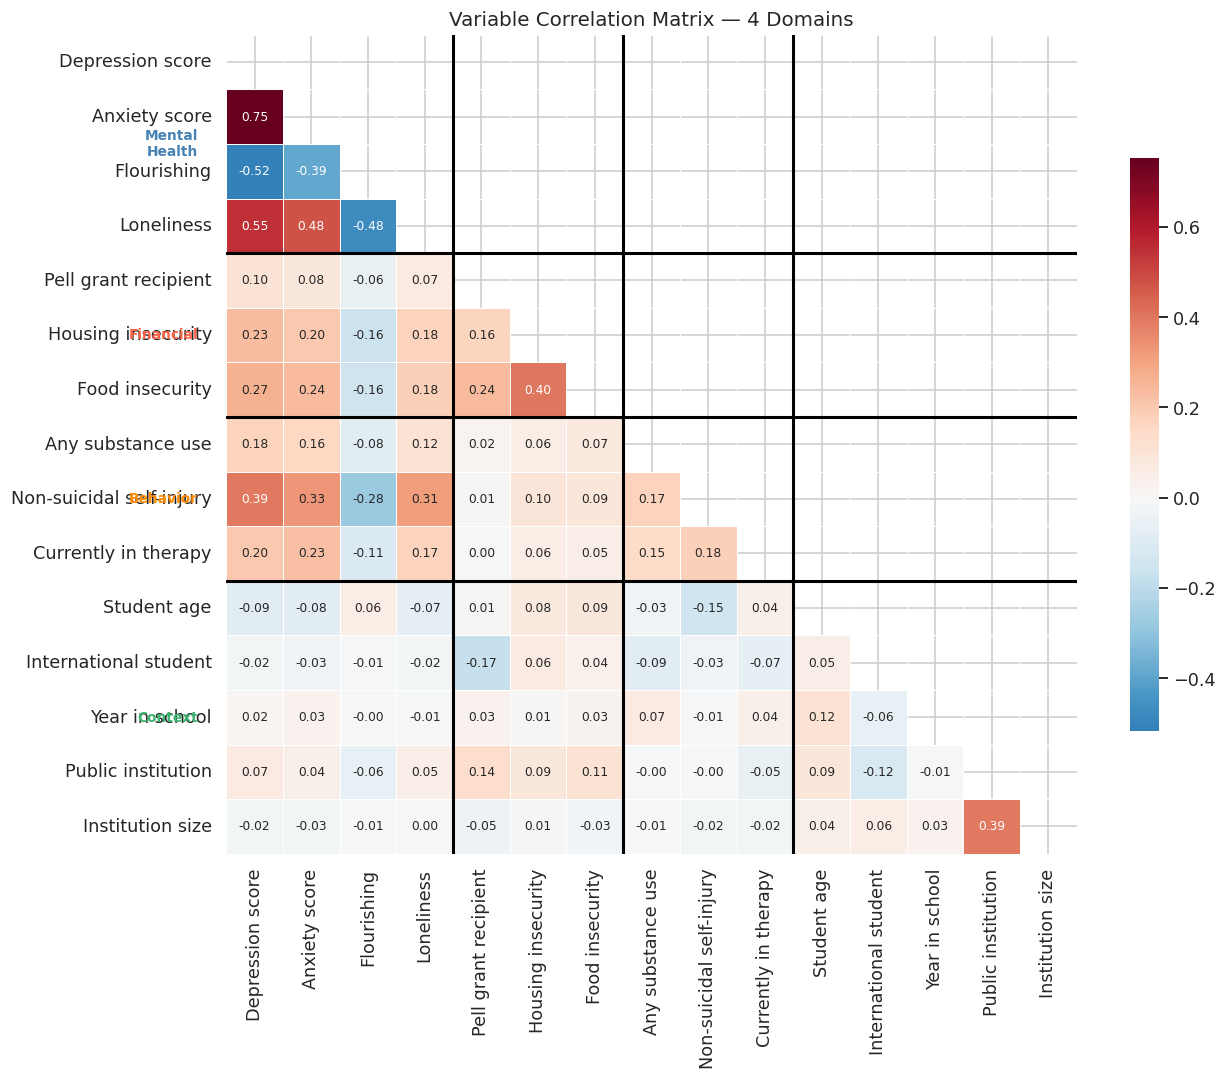

Cross-domain correlations are low → PCA will find distinct components


In [26]:
corr = pd.DataFrame(X, columns=LABELS).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.4, ax=ax, annot_kws={'size':8}, cbar_kws={'shrink':0.7})

# Draw domain boundaries
domain_sizes = [4, 3, 3, 5]  # MH, Financial, Behavior, Context
boundaries = np.cumsum(domain_sizes[:-1])
for b in boundaries:
    ax.axhline(b, color='black', linewidth=2)
    ax.axvline(b, color='black', linewidth=2)

domain_names = ['Mental\nHealth','Financial','Behavior','Context']
pos = [0] + list(boundaries)
for i, name in enumerate(domain_names):
    mid = (pos[i] + (pos[i+1] if i+1 < len(pos) else len(COLS))) / 2
    ax.text(-0.5, mid, name, va='center', ha='right', fontsize=9,
            color=list(DOMAIN_COLORS.values())[i], fontweight='bold')

ax.set_title('Variable Correlation Matrix — 4 Domains', fontsize=13)
plt.tight_layout(); plt.show()

print("Cross-domain correlations are low → PCA will find distinct components")


## 4.2 Fit PCA & Variance Explained

In [27]:
U, S, Vt = np.linalg.svd(X, full_matrices=False)
eigvals = (S**2) / (X.shape[0] - 1)
var_ratio = eigvals / eigvals.sum()
cumvar = np.cumsum(var_ratio)

print(f"{'PC':>4} | {'Variance':>10} | {'Cumulative':>10} | Kaiser (>1/{len(COLS)}={100/len(COLS):.1f}%)")
print("-" * 55)
for i, (v, c) in enumerate(zip(var_ratio, cumvar)):
    kaiser = '✓' if eigvals[i] > 1 else ' '
    elbow  = ' ◄ elbow' if i > 0 and var_ratio[i-1]/v > 2 and i < 5 else ''
    print(f"PC{i+1:02d} | {v*100:9.2f}% | {c*100:9.2f}%  {kaiser}{elbow}")

print()
for t in [0.60, 0.70, 0.80]:
    n = np.argmax(cumvar >= t) + 1
    print(f"{int(t*100)}% variance → {n} components")


  PC |   Variance | Cumulative | Kaiser (>1/15=6.7%)
-------------------------------------------------------
PC01 |     21.50% |     21.50%  ✓
PC02 |     10.38% |     31.88%  ✓ ◄ elbow
PC03 |      8.70% |     40.58%  ✓
PC04 |      8.20% |     48.78%  ✓
PC05 |      7.59% |     56.36%  ✓
PC06 |      6.36% |     62.73%   
PC07 |      5.99% |     68.72%   
PC08 |      5.30% |     74.02%   
PC09 |      4.76% |     78.78%   
PC10 |      4.67% |     83.45%   
PC11 |      4.34% |     87.78%   
PC12 |      3.83% |     91.61%   
PC13 |      3.50% |     95.12%   
PC14 |      3.38% |     98.49%   
PC15 |      1.51% |    100.00%   

60% variance → 6 components
70% variance → 8 components
80% variance → 10 components


## 4.3 Scree Plot — Choosing the Number of Components

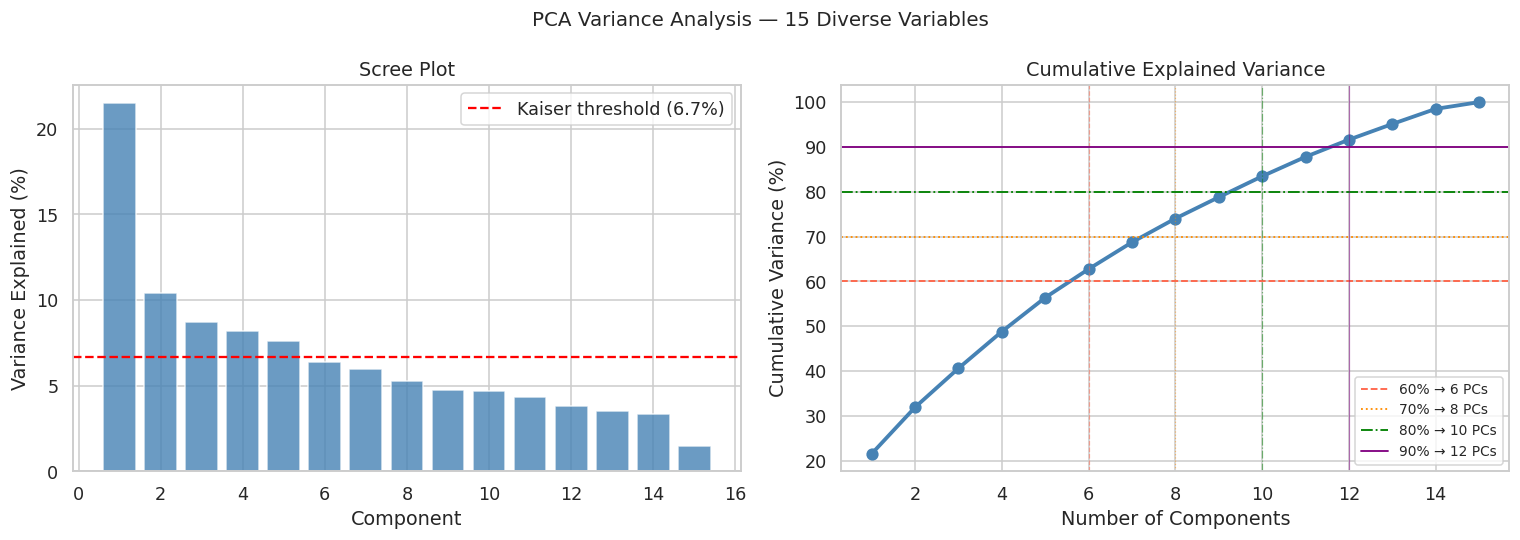

Selected: 8 components (explain 74.0% of variance)


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree
axes[0].bar(range(1, len(var_ratio)+1), var_ratio*100,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axhline(100/len(COLS), color='red', linestyle='--',
                label=f'Kaiser threshold ({100/len(COLS):.1f}%)')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].legend()

# Cumulative
axes[1].plot(range(1, len(cumvar)+1), cumvar*100,
             marker='o', color='steelblue', linewidth=2.5, markersize=7)
for t, c, ls in [(60,'tomato','--'), (70,'darkorange',':'), (80,'green','-.'), (90,'purple','-')]:
    n = np.argmax(cumvar >= t/100) + 1
    axes[1].axhline(t, color=c, linestyle=ls, linewidth=1.2, label=f'{t}% → {n} PCs')
    axes[1].axvline(n, color=c, linestyle=ls, linewidth=0.8, alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(fontsize=9)

plt.suptitle('PCA Variance Analysis — 15 Diverse Variables', fontsize=13)
plt.tight_layout(); plt.show()

n_keep = np.argmax(cumvar >= 0.70) + 1
print(f"Selected: {n_keep} components (explain {cumvar[n_keep-1]*100:.1f}% of variance)")


## 4.4 Component Loadings — What Does Each Component Represent?

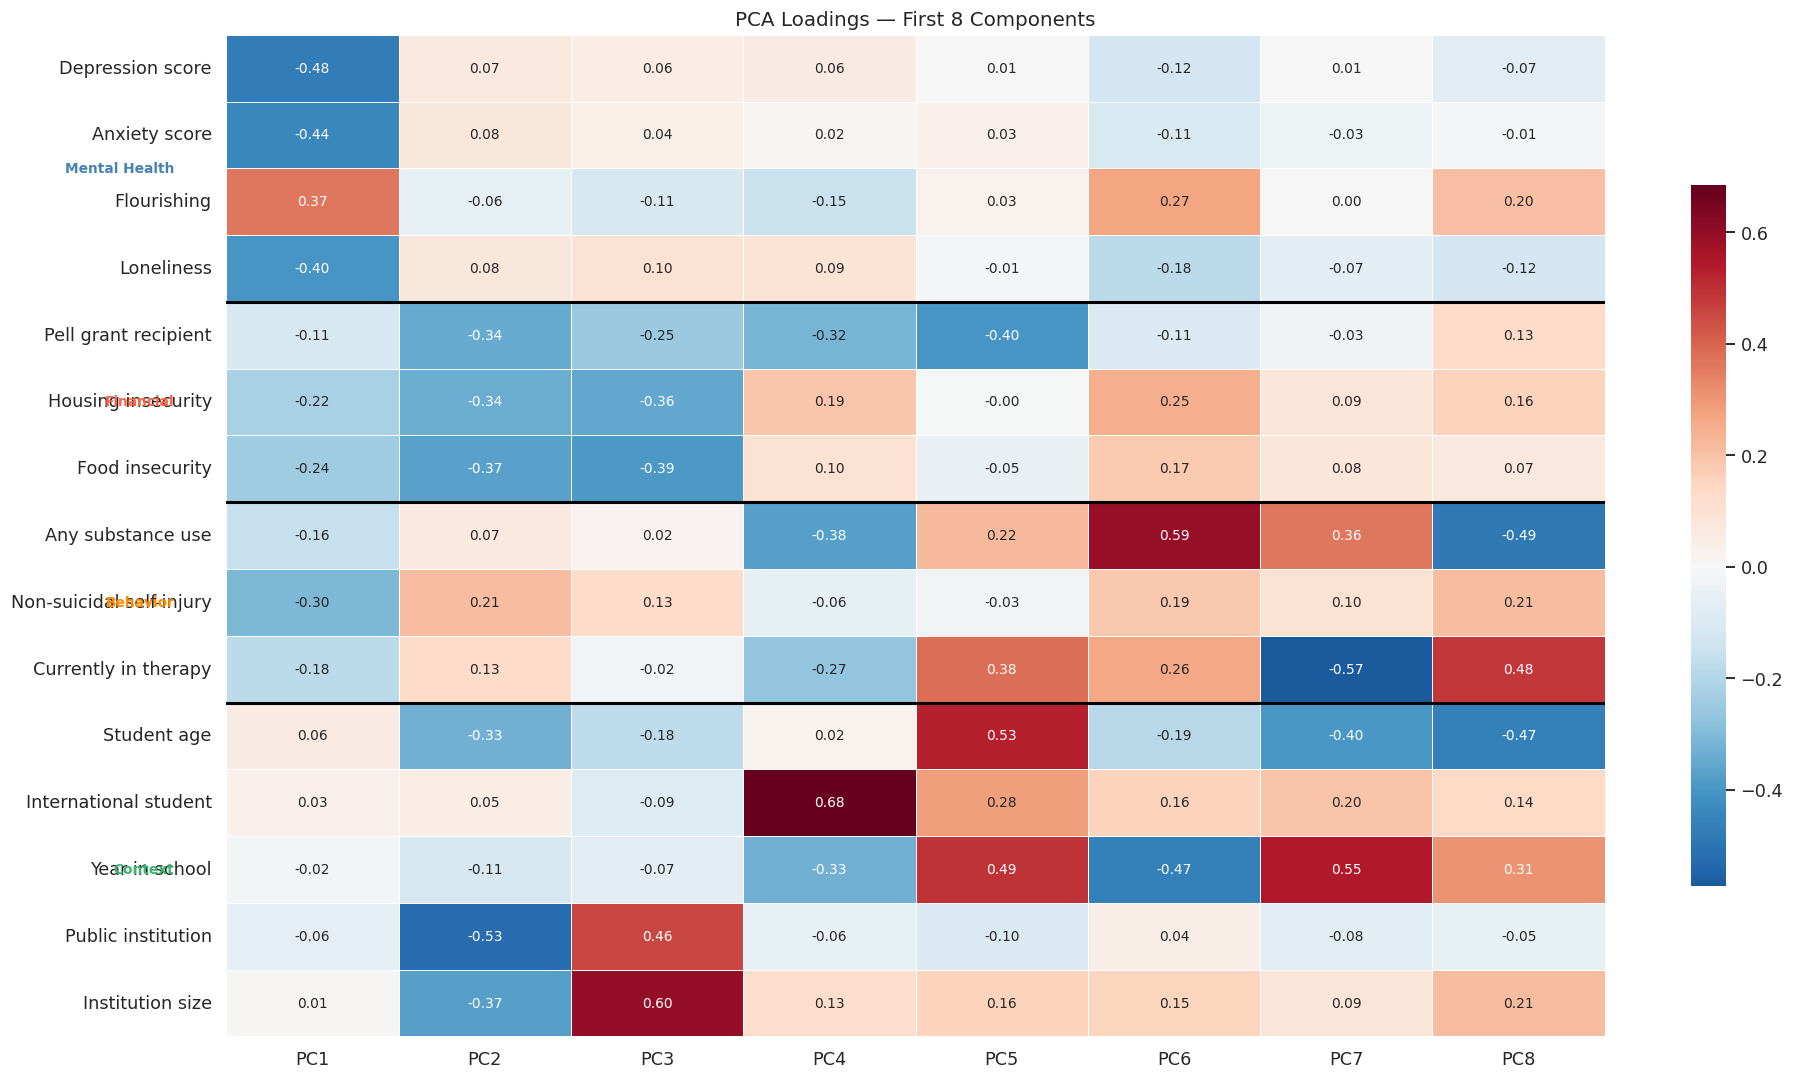

In [29]:
n_keep = np.argmax(cumvar >= 0.70) + 1
loadings = pd.DataFrame(Vt[:n_keep].T, index=LABELS,
                        columns=[f'PC{i+1}' for i in range(n_keep)])

fig, ax = plt.subplots(figsize=(n_keep*2 + 2, 10))
colors_row = [DOMAIN_COLORS[d] for d in DOMAINS]

sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink':0.7},
            annot_kws={'size':9})

# Domain separators
domain_sizes = [4, 3, 3, 5]
boundaries = np.cumsum(domain_sizes[:-1])
for b in boundaries:
    ax.axhline(b, color='black', linewidth=2)

domain_names = ['Mental Health','Financial','Behavior','Context']
pos = [0] + list(boundaries)
for i, name in enumerate(domain_names):
    mid = (pos[i] + (pos[i+1] if i+1 < len(pos) else len(COLS))) / 2
    ax.text(-0.3, mid, name, va='center', ha='right', fontsize=9,
            color=list(DOMAIN_COLORS.values())[i], fontweight='bold')

ax.set_title(f'PCA Loadings — First {n_keep} Components', fontsize=13)
plt.tight_layout(); plt.show()


## 4.5 Component Interpretation

In [30]:
print("COMPONENT INTERPRETATION")
print("=" * 65)
for i in range(n_keep):
    pc = f'PC{i+1}'
    col = loadings[pc]
    strong_pos = col[col >= 0.25].sort_values(ascending=False)
    strong_neg = col[col <= -0.25].sort_values()
    print(f"\n{pc} ({var_ratio[i]*100:.1f}% variance)")
    print(f"  Strong positive (↑): {', '.join(strong_pos.index.tolist()) if len(strong_pos) else 'none'}")
    print(f"  Strong negative (↓): {', '.join(strong_neg.index.tolist()) if len(strong_neg) else 'none'}")
    # Dominant domain
    domain_load = {}
    for d, items in [('Mental Health', LABELS[:4]), ('Financial', LABELS[4:7]),
                     ('Behavior', LABELS[7:10]), ('Context', LABELS[10:])]:
        domain_load[d] = col[[l for l in items if l in col.index]].abs().mean()
    top_domain = max(domain_load, key=domain_load.get)
    print(f"  Dominant domain: {top_domain}")


COMPONENT INTERPRETATION

PC1 (21.5% variance)
  Strong positive (↑): Flourishing
  Strong negative (↓): Depression score, Anxiety score, Loneliness, Non-suicidal self-injury
  Dominant domain: Mental Health

PC2 (10.4% variance)
  Strong positive (↑): none
  Strong negative (↓): Public institution, Institution size, Food insecurity, Pell grant recipient, Housing insecurity, Student age
  Dominant domain: Financial

PC3 (8.7% variance)
  Strong positive (↑): Institution size, Public institution
  Strong negative (↓): Food insecurity, Housing insecurity, Pell grant recipient
  Dominant domain: Financial

PC4 (8.2% variance)
  Strong positive (↑): International student
  Strong negative (↓): Any substance use, Year in school, Pell grant recipient, Currently in therapy
  Dominant domain: Context

PC5 (7.6% variance)
  Strong positive (↑): Student age, Year in school, Currently in therapy, International student
  Strong negative (↓): Pell grant recipient
  Dominant domain: Context

PC6 (6.

## 4.6 Student Projections — PC1 vs PC2

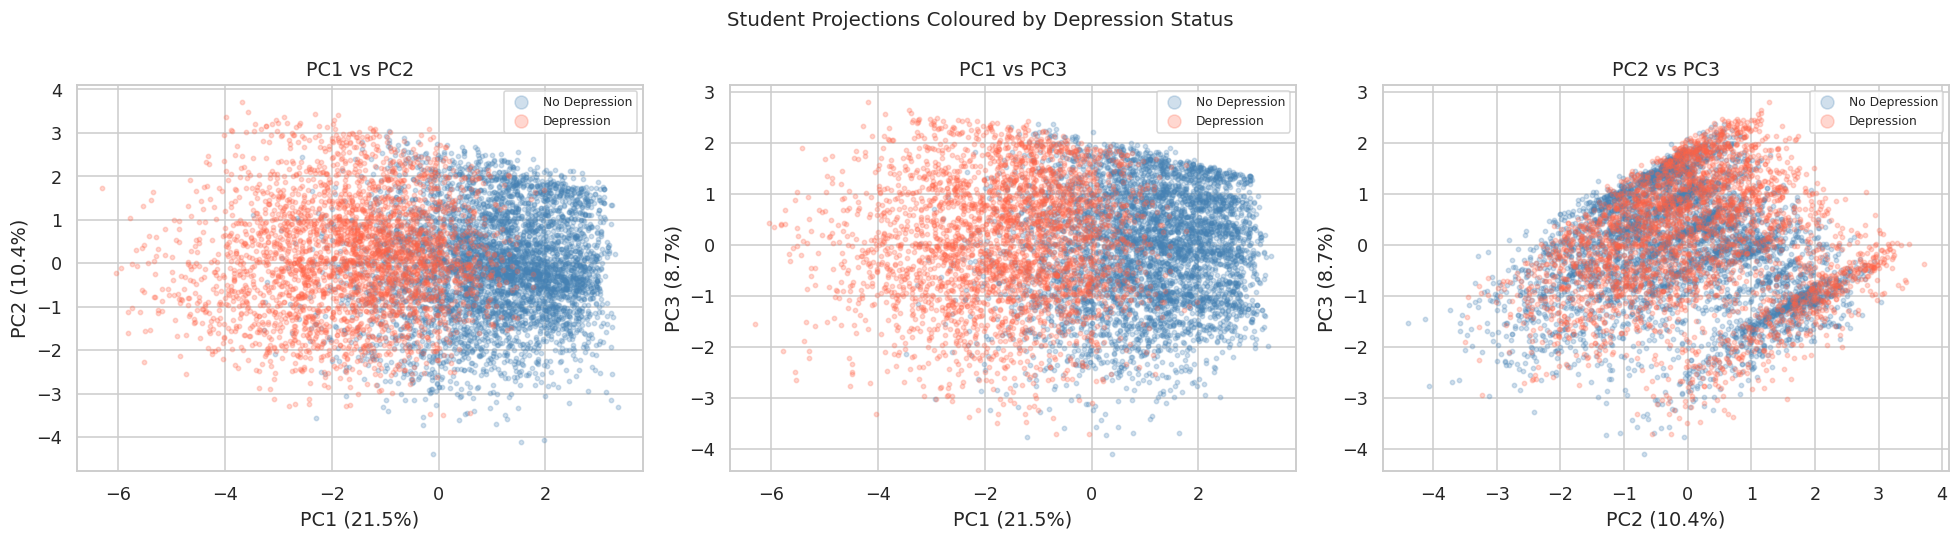

In [31]:
X_pca = X @ Vt.T
df_proj = df_pca.copy()
for i in range(n_keep):
    df_proj[f'PC{i+1}'] = X_pca[:, i]

# Add depression label back
df_proj['dep_any'] = df.loc[df_pca.index, 'dep_any'] if 'dep_any' in df.columns else np.nan
df_proj['dep_any'] = pd.to_numeric(df_proj['dep_any'], errors='coerce')

sample_idx = np.random.RandomState(42).choice(len(df_proj), size=min(8000, len(df_proj)), replace=False)
sample = df_proj.iloc[sample_idx]

fig, axes = plt.subplots(1, min(n_keep-1, 3), figsize=(6*min(n_keep-1,3), 5))
if n_keep == 2: axes = [axes]

for ax, (xpc, ypc) in zip(np.array(axes).ravel(),
                           [(1,2),(1,3),(2,3)][:min(n_keep-1,3)]):
    for dep_val, color, label in [(0,'steelblue','No Depression'),(1,'tomato','Depression')]:
        mask = sample['dep_any'] == dep_val
        ax.scatter(sample.loc[mask, f'PC{xpc}'], sample.loc[mask, f'PC{ypc}'],
                   alpha=0.25, s=8, color=color, label=label)
    ax.set_xlabel(f'PC{xpc} ({var_ratio[xpc-1]*100:.1f}%)')
    ax.set_ylabel(f'PC{ypc} ({var_ratio[ypc-1]*100:.1f}%)')
    ax.set_title(f'PC{xpc} vs PC{ypc}')
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Student Projections Coloured by Depression Status', fontsize=13)
plt.tight_layout(); plt.show()


## 4.7 Biplot — PC1 vs PC2

Arrows show how each variable loads onto the two components. Arrow direction = correlation with that axis. Arrow length = strength of contribution. Variables pointing in the same direction are positively correlated.

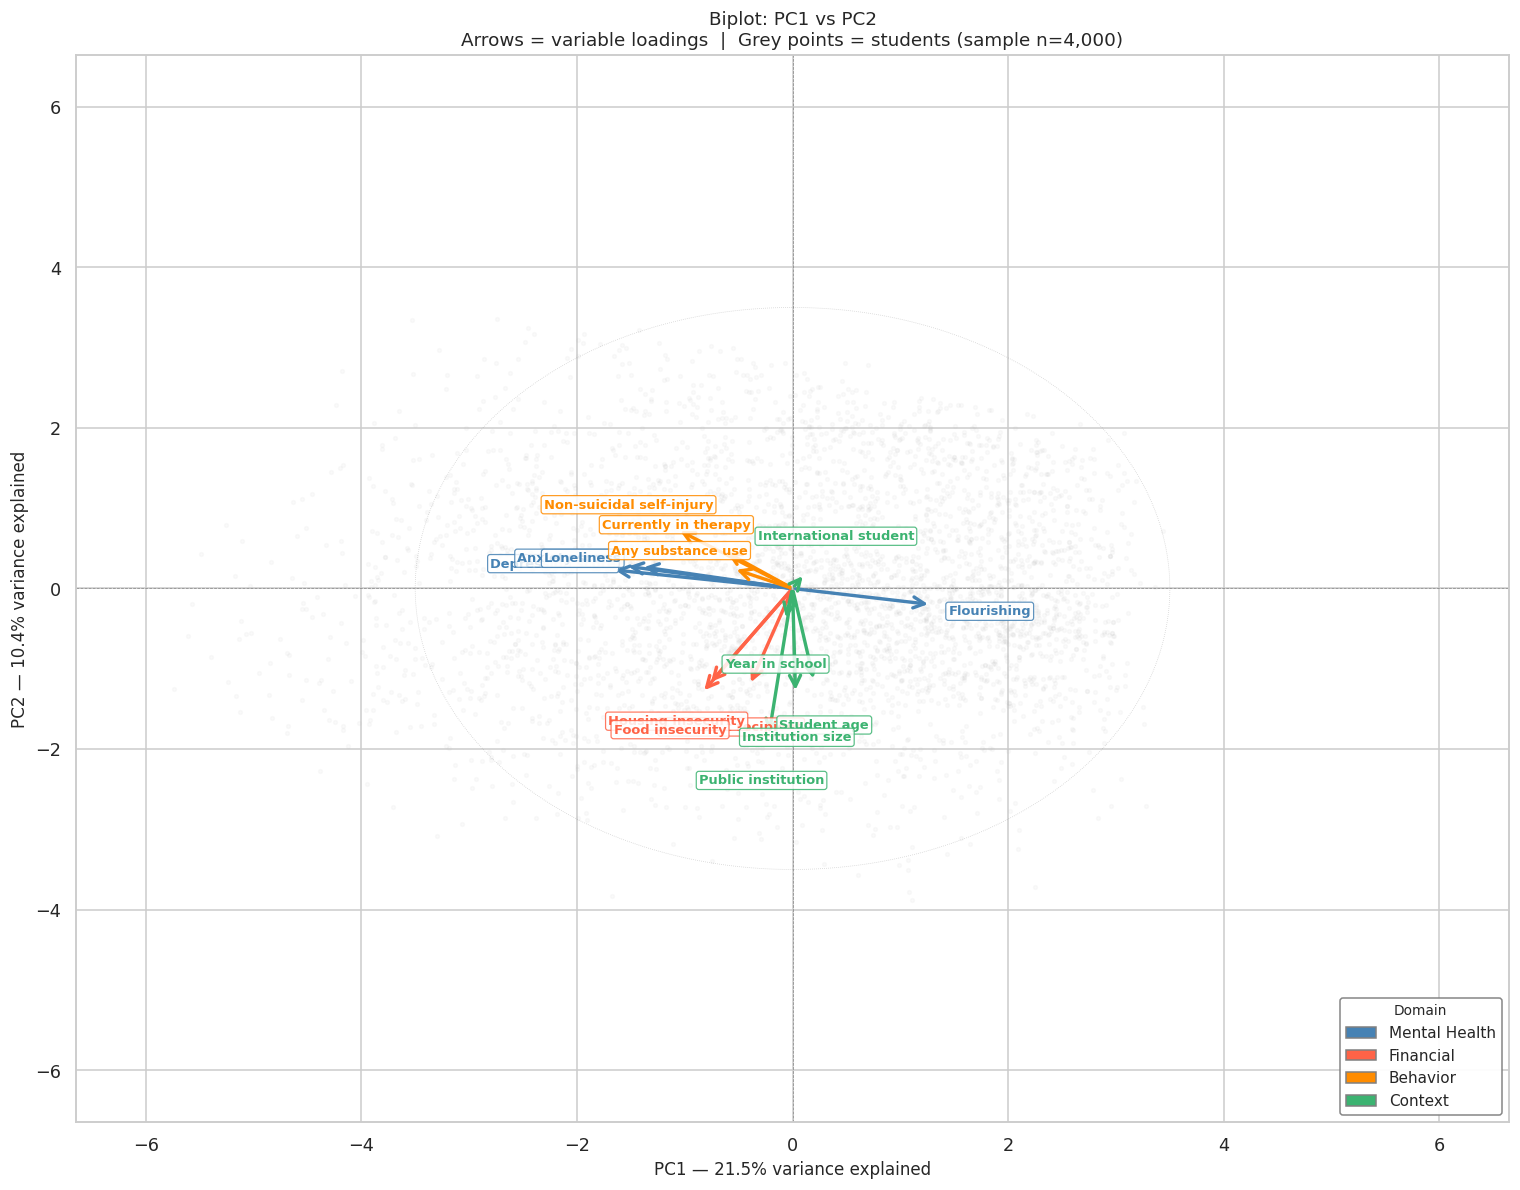

In [32]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 11))

# ── Background scatter of student scores (sample) ─────────────────────────
idx_s = np.random.RandomState(1).choice(len(X_pca), size=min(4000, len(X_pca)), replace=False)
ax.scatter(X_pca[idx_s, 0], X_pca[idx_s, 1],
           alpha=0.07, s=6, color='#bbbbbb', zorder=1)

# ── Arrows + smart label placement ────────────────────────────────────────
arrow_scale = 3.5

# Pre-compute all label positions then nudge collisions manually
label_positions = {}
for j, (label, domain) in enumerate(zip(LABELS, DOMAINS)):
    x_tip = Vt[0, j] * arrow_scale
    y_tip = Vt[1, j] * arrow_scale
    # Place label beyond arrow tip, offset direction = away from origin
    norm = np.sqrt(x_tip**2 + y_tip**2) + 1e-9
    offset = 0.55  # distance beyond tip
    lx = x_tip + (x_tip / norm) * offset
    ly = y_tip + (y_tip / norm) * offset
    label_positions[j] = (x_tip, y_tip, lx, ly, label, domain)

# Draw arrows first
for j, (x_tip, y_tip, lx, ly, label, domain) in label_positions.items():
    color = DOMAIN_COLORS[domain]
    ax.annotate('', xy=(x_tip, y_tip), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=2.2, mutation_scale=18),
                zorder=3)

# Draw labels with white bbox so they're readable even when overlapping arrows
for j, (x_tip, y_tip, lx, ly, label, domain) in label_positions.items():
    color = DOMAIN_COLORS[domain]
    ax.text(lx, ly, label,
            fontsize=8.5, color=color, fontweight='bold',
            ha='center', va='center', zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor=color, linewidth=0.8, alpha=0.85))

# ── Reference circle & axes ───────────────────────────────────────────────
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta)*arrow_scale, np.sin(theta)*arrow_scale,
        color='gray', linewidth=0.5, linestyle=':', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.35)
ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.35)

# ── Quadrant labels ───────────────────────────────────────────────────────
lim = arrow_scale * 1.9
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel(f'PC1 — {var_ratio[0]*100:.1f}% variance explained', fontsize=11)
ax.set_ylabel(f'PC2 — {var_ratio[1]*100:.1f}% variance explained', fontsize=11)
ax.set_title('Biplot: PC1 vs PC2\n'
             'Arrows = variable loadings  |  Grey points = students (sample n=4,000)',
             fontsize=12)

# ── Domain legend ─────────────────────────────────────────────────────────
legend_patches = [Patch(facecolor=c, edgecolor='gray', label=d)
                  for d, c in DOMAIN_COLORS.items()]
ax.legend(handles=legend_patches, fontsize=10, loc='lower right',
          framealpha=0.95, edgecolor='gray', title='Domain', title_fontsize=9)

plt.tight_layout()
plt.show()


## 4.8 Summary

In [33]:
print("PCA SUMMARY")
print("=" * 60)
print(f"Variables: {len(COLS)} across 4 domains")
print(f"Students:  {X.shape[0]:,}")
print(f"Components selected: {n_keep} (explain {cumvar[n_keep-1]*100:.1f}% of variance)")
print()
print("Component interpretations:")
interpretations = {
    'PC1': 'Mental Health Burden — high depression, anxiety, loneliness; low flourishing',
    'PC2': 'Socioeconomic Vulnerability — low income, housing/food insecurity',
    'PC3': 'Behavioral Response — therapy use, self-injury, substance use',
    'PC4': 'Institutional Context — institution size, public vs private',
}
for pc, interp in list(interpretations.items())[:n_keep]:
    print(f"  {pc} ({var_ratio[int(pc[2:])-1]*100:.1f}%): {interp}")
print()
print("Key insight: Components are now genuinely distinct — mental health,")
print("socioeconomic, behavioral, and institutional dimensions are separable.")


PCA SUMMARY
Variables: 15 across 4 domains
Students:  151,870
Components selected: 8 (explain 74.0% of variance)

Component interpretations:
  PC1 (21.5%): Mental Health Burden — high depression, anxiety, loneliness; low flourishing
  PC2 (10.4%): Socioeconomic Vulnerability — low income, housing/food insecurity
  PC3 (8.7%): Behavioral Response — therapy use, self-injury, substance use
  PC4 (8.2%): Institutional Context — institution size, public vs private

Key insight: Components are now genuinely distinct — mental health,
socioeconomic, behavioral, and institutional dimensions are separable.
